<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/Interview_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- How indexing works in sets
- Why dict key cant be mutable data types
- Enumerate
- destructor
- dir/isinstance/issubclass
- classmethod vs staticmethod
- The diamond problem
- What’s the meaning of single and double underscores in Python variable and method names
- Magic Methods (repr vs str)
- How can objects be stored in sets even though they are mutable


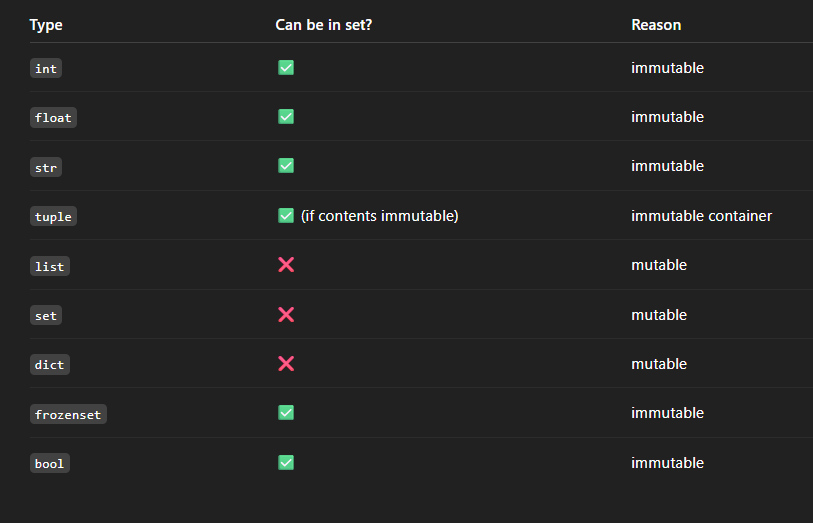

In [28]:
d = {[1,2,3]:'shaurya'}
d

TypeError: unhashable type: 'list'

In [10]:
# by hashing concept the ordering in sets is changed, the hashing function decides the ordering
# dict preserves insertion order (Python 3.7+)

# hashing - whenever we are prestoring values in pyhton , then it is called hashing
# but why? 1. because hashing enables us to do searching in O(1) (same in dictionary)  2. sets nedd to store values to remove duplicates (my guess)

s = {32,31,4}
print(s)
for i,j in enumerate(s):
  print(i,j)

{32, 4, 31}
0 32
1 4
2 31


In [16]:
# enumerate

t = [12,18,20,32,32]

enumerate(t)
print(type(enumerate(t)))
list(enumerate(t, start =10))  # need to be converted into a list from object

# does not provide indexes, but counter, proved by the start attribute

<class 'enumerate'>


[(10, 12), (11, 18), (12, 20), (13, 32), (14, 32)]

In [23]:
# The enumerate() method adds counter to an iterable and returns it (the enumerate object)

l = [("Shaurya", 120),("Rahul", 95),("Rohit", 91)]

print(sorted(l))  # sorts on the basis of the first value
print(sorted(l, key = lambda x:x[1]))  # sorts on the basis of the second value
print(sorted(l, reverse=True))   # reverse the sorted list

[('Rahul', 95), ('Rohit', 91), ('Shaurya', 120)]
[('Rohit', 91), ('Rahul', 95), ('Shaurya', 120)]
[('Shaurya', 120), ('Rohit', 91), ('Rahul', 95)]


In [27]:
# constructor - magic method which is automatically triggered when object is "created" . generally contains configuration related code. i.e code which you want to automatically execute and dont want the user to intervene in it. eg connecting to database
# destructor - magic method which is triggered when the object is "destroyed". also contains configuration related code which you want to run before ending the program. for eg closing connection to database, closing connection to the inteernet,
              # not called until all the objects created are deleted
              # not very useful in python
class Example:

  def __init__(self):
    print("Constructor called")

  def __del__(self):
    print("Destructor called")

obj = Example()
del obj

Constructor called
Destructor called


In [29]:
# dir

class Test:
    def __init__(self):
        self.foo = 11
        self._bar = 23
        self.__baz = 23

    def greet(self):
      print('hello')

t = Test()
print(dir(t)) # This gives us a list with the object’s attributes

# all the magic methods, methods(private / public),  attributes( private/ public) are printed

# __baz is actually stored in memory in the format _<className>__<attribute>  so it becomes: _Test__baz
# this is known as "name mangling"

['_Test__baz', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_bar', 'foo', 'greet']


In [31]:
# isinstance - tells whether an object is an instance of a class or not
isinstance(t, Test)

True

In [36]:
# issubclass - tells whether the first class is subclass of second class or not
class A:
  def __init__(self):
    print("A")

class B(A):
  def __init__(self):
    print("B")

print(issubclass(A, B))
print(issubclass(B, A))
print(issubclass(A, A))
print(issubclass(B, B))  # Every class is a subclass of itself.

False
True
True
True




---



### Class method vs Static Method<br>
The difference between the Class method and the static method is:

- A class method takes cls as the first parameter while a static method needs no specific parameters.
- A class method can access or modify the class state while a static method can’t access or modify it.
- In general, static methods know nothing about the class state. They are utility-type methods that take some parameters and work upon those parameters. On the other hand class methods must have class as a parameter.
- We use @classmethod decorator in python to create a class method and we use @staticmethod decorator to create a static method in python.

### When to use the class or static method?
- We generally use the class method to create factory methods. Factory methods return class objects ( similar to a constructor ) for different use cases.
- We generally use static methods to create utility functions.

In [ ]:
# classmethod vs static method




---



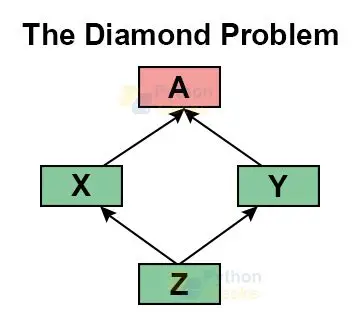

In [41]:
# The Diamond Problem

# suppose the inheritance looks like in the diagram above
# classes A, X, Y have method m1 but class Z does not
# so if we try to call method m1 through Z whose m1 will be executed

class A:
  def __init__(self) -> None:
    print("A")

  def m1(self):
    print("m1 of A")

class X(A):
  def __init__(self) -> None:
    print("X")

  def m1(self):
    print("m1 of X")

class Y(A):
  def __init__(self) -> None:
    print("Y")

  def m1(self):
    print("m1 of Y")

class Z(X, Y):
  def __init__(self) -> None:
    print("Z")

# the exeution order depends on the (X,y).
# the class written first will be executed first and hence its m1 will be executed
# this is called method resolution order

d = Z()
d.m1()

Z
m1 of X


* Single Leading Underscore: `_var`
* Single Trailing Underscore: `var_`
* Double Leading Underscore: `__var`
* Double Leading and Trailing Underscore: `__var__`
* Single Underscore: `_`

1. **Single Leading Underscore:** `_var` are a Python naming convention that indicates a name is meant for internal use. It is generally not enforced by the
Python interpreter and is only meant as a hint to the programmer.

 Adding a single underscore in front of a variable name is more like someone putting up a tiny underscore warning sign that says:

> “Hey, this isn’t really meant to be a part of the public interface of this class. Best to leave it alone.”

2. **Single Trailing Underscore:** `var_`
 Sometimes the most fitting name for a variable is already taken by a keyword in the Python language. Therefore, names like class or def cannot be used as variable names in Python. In this case, you can append a single underscore to break the naming conflict:



3. **Double Leading Underscore**: `__var`

A double underscore prefix causes the Python interpreter to rewrite
the attribute name in order to avoid naming conflicts in subclasses.

This is also called *name mangling*—the interpreter changes the name
of the variable in a way that makes it harder to create collisions when
the class is extended later.

4. **Double Leading and Trailing Underscore**: `__var__`

Double underscores `__` are often referred to as “**dunders**” in the Python
community. The reason is that double underscores appear quite often
in Python code, and to avoid fatiguing their jaw muscles, Pythonistas
often shorten “**double underscore**” to “**dunder**.”

The names that have both leading and trailing double underscores are reserved for special use in the language. This rule covers things like `__init__` for object constructors, or `__call__` to make objects callable.

These dunder methods are often referred to as magic methods.

There are many dunder methods, here are some:-

`__str__, __repr__, __call__, __add__, __sub__, __len__` etc.



5. **Single Underscore** `_`:
 Sometimes used as a name for temporary or insignificant variables (“don’t care). Also, it represents the result of the last expression in a Python REPL session.


In [42]:
for _ in range(2):
  print("Shaurya")

Shaurya
Shaurya




---



### **`5. What is the difference between OOP and SOP?`**

| Object Oriented Programming | Structural Programming|
| :-- | :-- |
| Object-Oriented Programming is a type of programming which is based on objects rather than just functions and procedures | Provides logical structure to a program where programs are divided functions |
| Bottom-up approach | Top-down approach |
| Provides data hiding | Does not provide data hiding |
| Can solve problems of any complexity | Can solve moderate problems |
| Code can be reused thereby reducing redundancy | Does not support code reusability |

### **`6. Can you call the base class method without creating an instance?`**

Yes, you can call the base class without instantiating it if:
- It is a static method
- The base class is inherited by some other subclass

### **`7. What are the limitations of inheritance?`**

- Increases the time and effort required to execute a program as it requires jumping back and forth between different classes.
- The parent class and the child class get tightly coupled.
- Any modifications to the program would require changes both in the parent as well as the child class
- Needs careful implementation else would lead to incorrect results

### **`8. What is the difference between range() and xrange()?`**

- range() creates a static list that can be iterated through while checking some conditions. This is a function that returns a list with integer sequences.
- xrange() is same in functionality as range() but it does not return a list, instead it returns an object of xrange(). xrange() is used in generators for yielding.

| range() | xrange() |
| :-- | :-- |
| In Python 3, xrange() is not supported; instead, the range() function is used to iterate in for loops. | The xrange() function is used in Python 2 to iterate in for loops.
| It returns a list. | It returns a generator object as it doesn’t really generate a static list at the run time. |
| It takes more memory as it keeps the entire list of iterating numbers in memory. | It takes less memory as it keeps only one number at a time in memory. |



---



### In summary

- str is for users -> meant to be more readable
- repr is for developers for debugging - > for being unambigous

 repr ---> representation

In [43]:
# repr and other magic/dunder methods

a = 'hello'

print(str(a))
print(repr(a))

hello
'hello'


In [44]:
import datetime

a = datetime.datetime.now()
b = str(a)

print(str(a))
print(str(b))

print(repr(a))
print(repr(b))

2026-03-25 11:08:16.799554
2026-03-25 11:08:16.799554
datetime.datetime(2026, 3, 25, 11, 8, 16, 799554)
'2026-03-25 11:08:16.799554'




---



#How can objects be stored in sets even though they are mutable

In [54]:
# how objects are stored even though they are mutable
# https://stackoverflow.com/questions/31340756/python-why-can-i-put-mutable-object-in-a-dict-or-set

class A:

  def __init__(self):
    print('constructor')

  def hello(self):
    print('hello')

a = A()
a.hello()
s = {a}  # this hould not run according to our previos knowledge , i.e objects are mutable, and sets cant store mutable items.
print(s)
dir(a)



constructor
hello
{<__main__.A object at 0x7cfd6eedebd0>}


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'hello']

In [51]:
# sets do not want immutable objects, instead they want unhashable objects and so this error occurs.
s={[1,2]}

TypeError: unhashable type: 'list'

In [52]:
class A:

  def __init__(self):
    print('constructor')

  def __eq__(self):
    pass

  # def __hash__(self) -> int:      (default hash function) this hash function does not return integer and hence it does not make the object hashable, and hence not allowed in sets
  #   pass

  def __hash__(self):  # the hash function here returns an integer and hence it makes the object hashable, and hence can be stored in sets
    return 1

  def hello(self):
    print('hello')

a = A()
a.hello()
s = {a}
print(s)

dir(a)

constructor
hello
{<__main__.A object at 0x7cfd6ec712e0>}


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'hello']



---



# Decorators

Python offers a unique feature called decorators.

Let's start with an analogy before getting to the technical definition of the decorators. When we mention the word "decorator", what enters your mind? Well, likely something that adds beauty to an existing object. An example is when we hang a picture frame to a wall to enhance the room.

Decorators in Python add some feature or functionality to an existing function without altering it.

Let's say we have the following simple function that takes two numbers as parameters and divides them.


```
def divide(first, second):
    print ("The result is:", first/second)
```
Now if we call this function by passing the two values 16 and 4, it will return the following output:


```
divide(16, 4)
```
The output is:

`The result is: 4.0`





---



### **`9. How to override the way objects are printed?`**

Use the `__str__` and the `__repr__` dunder methods.

Here’s an example that demonstrates how an instance from the Person class can be nicely formatted when printed to the console.

In [57]:
class Person:
    def __init__(self, first_name, last_name, age):
        self.first_name = first_name
        self.last_name = last_name
        self.age = age

    def __str__(self):
        return f"{self.first_name} {self.last_name} ({self.age})"

    def __repr__(self):
        return f"{self.first_name} {self.last_name} ({self.age})"

person = Person("John", "Doe", 30) # thanks to __str__
person

John Doe (30)

Let’s begin by writing a (Python 3) class that contains simple examples
for all three method types:
```
class MyClass:

    def method(self):
        return 'instance method called', self

    @classmethod
    def classmethod(cls):
        return 'class method called', cls

    @staticmethod
    def staticmethod():
        return 'static method called'
```

**`Instance Methods`**

The first method on `MyClass`, called `method`, is a regular instance method. That’s the basic, no-frills method type you’ll use most of the time. You can see the method takes one parameter, self, which points to an instance of MyClass when the method is called. But of course, instance methods can accept more than just one parameter.

Through the self parameter, instance methods can freely access attributes and other methods on the same object. This gives them a lot of power when it comes to modifying an object’s state.

Not only can they modify object state, instance methods can also access the class itself through the `self.__class__` attribute. This means instance methods can also modify class state.  This makes instance methods powerful in terms of access restrictions—they can freely modify state on the object instance and on the class itself.




**`Class Methods`**

Let’s compare that to the second method, `MyClass.classmethod`. I marked this method with a [`@classmethod`](https://docs.python.org/3/library/functions.html#classmethod) decorator to flag it as a class method. Instead of accepting a self parameter, class methods take a `cls` parameter that points to the class—and *not* the object instance—when the method is called.

Since the class method only has access to this `cls` argument, it can’t modify object instance state. That would require access to self. However, class methods can still modify class state that applies across all instances of the class.

`Static Methods`

The third method, `MyClass.staticmethod` was marked with a [`@staticmethod6`](https://docs.python.org/3/library/functions.html#staticmethod) decorator to flag it as a static method.

This type of method doesn’t take a `self` or a `cls` parameter, although, of course, it can be made to accept an arbitrary number of other parameters.

As a result, a static method cannot modify object state or class state.
Static methods are restricted in what data they can access—they’re primarily a way to namespace your methods.

In [64]:
# Class

class MyClass:

    def method(self):
        return 'instance method called', self

    @classmethod
    def classmethod(cls):
        return 'class method called', cls

    @staticmethod
    def staticmethod():
        return 'static method called'


In [65]:
type(obj)

__main__.MyClass

In [66]:
obj = MyClass()
obj.method()

('instance method called', <__main__.MyClass at 0x7cfd6ec700b0>)

This confirms that, in this case, the instance method called method has access to the object instance (printed as `<MyClass instance>`) via the self argument.

When the method is called, Python replaces the `self` argument with the instance object, `obj`.

We could ignore the syntactic sugar provided by the `obj.method()` **dot-call syntax** and pass the instance object manually to get the same result:
```
MyClass.method(obj)
```


In [67]:
MyClass.method(obj)

('instance method called', <__main__.MyClass at 0x7cfd6ec700b0>)

Did you see how we called `staticmethod()` on the object and were able to do so successfully? Some developers are surprised when they learn that it’s possible to call a static method on an object instance.

Behind the scenes, Python simply enforces the access restrictions by
not passing in the `self` or the `cls` argument when a static method gets
called using the dot syntax

This confirms that static methods can neither access the object instance state nor the class state. They work like regular functions but belong to the class’ (and every instance’s) namespace.

Now, let’s take a look at what happens when we attempt to call these
methods on the class itself, **without creating an object instance** beforehand:

In [68]:
# Class Method
print(MyClass.classmethod())
# Static method
print(MyClass.staticmethod())
#Instance Method
print(MyClass.method())

('class method called', <class '__main__.MyClass'>)
static method called


TypeError: MyClass.method() missing 1 required positional argument: 'self'

We were able to call `classmethod()` and `staticmethod(`) just fine, but attempting to call the instance method `method()` failed with a `TypeError`.

This is to be expected. This time we didn’t create an object instance and tried calling an instance function directly on the class blueprint itself. This means there is no way for Python to populate the `self` argument and therefore the call fails with a `TypeError exception`.

This should make the distinction between these three method types a
little more clear

**Key Takeaways**
* Instance methods need a class instance and can access the instance through `self`.
* Class methods don’t need a class instance. They can’t access the
instance (`self`) but they have access to the class itself via `cls`.
* Static methods don’t have access to `cls or self`. They work like
regular functions but belong to the class’ namespace.
* Static and class methods communicate and (to a certain degree)
enforce developer intent about class design. This can have definite maintenance benefits.



In [ ]:
https://colab.research.google.com/drive/1uVdKxoaOSgu1WZ1U5yyNieOLdudvBDRx